# Regression for Chemistry
We will look at regression for predicting molecule solubility, using the delaney dataset

# Install packages
Only run if you do not already have these packages

In [ ]:
%pip install rdkit
%pip install pandas
%pip install scikit-learn
%pip install matplotlib

# Load and process data
We will process the data the same way we did for classification, except this time we will not set a threshold because we want to predict the continuous value for solubility

In [1]:
import pandas as pd
from rdkit import Chem
from rdkit.Chem import Descriptors, AllChem, DataStructs
import numpy as np

#method we will use to convert fingerprint to an array that can be used later with scikit learn
def mol_to_fp_array(mol, radius=2, nBits=2048):
    if mol is None:
        return None
    
    fpgen_morgan = AllChem.GetMorganGenerator(radius=radius,fpSize=nBits)
    fp = fpgen_morgan.GetFingerprint(mol)
    
    arr = np.zeros((nBits,), dtype=np.float32)
    DataStructs.ConvertToNumpyArray(fp, arr)
    
    return arr

df = pd.read_csv("delaney.csv")

#calculate descriptors and add them to the dataframe
#Note - it can often help the model performance to scale the data within a standard range and/or to a normal distribution
#We will discuss how to do this in a future set of example code
df["mol"] = df["SMILES"].apply(Chem.MolFromSmiles)
df["hba"] = df["mol"].apply(lambda m: Descriptors.NumHAcceptors(m) if m is not None else pd.NA)
df["hbd"] = df["mol"].apply(lambda m: Descriptors.NumHDonors(m) if m is not None else pd.NA)
df["mw"] = df["mol"].apply(lambda m: Descriptors.MolWt(m) if m is not None else pd.NA)

#calculate fingerprints and add them to the dataframe

df["fp"] = df["mol"].apply(lambda m: mol_to_fp_array(m) if m is not None else pd.NA)

#this will let us see the beginning of the table
df.head()

,Compound ID,measured log(solubility:mol/L),ESOL predicted log(solubility:mol/L),SMILES,mol,hba,hbd,mw,fp
0,"1,1,1,2-Tetrachloroethane",-2.18,-2.794,ClCC(Cl)(Cl)Cl,<rdkit.Chem.rdchem.Mol object at 0x00000293A9D...,0,0,167.850,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
1,"1,1,1-Trichloroethane",-2.00,-2.232,CC(Cl)(Cl)Cl,<rdkit.Chem.rdchem.Mol object at 0x00000293A9D...,0,0,133.405,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
2,"1,1,2,2-Tetrachloroethane",-1.74,-2.549,ClC(Cl)C(Cl)Cl,<rdkit.Chem.rdchem.Mol object at 0x00000293A9D...,0,0,167.850,"[0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
3,"1,1,2-Trichloroethane",-1.48,-1.961,ClCC(Cl)Cl,<rdkit.Chem.rdchem.Mol object at 0x00000293A9D...,0,0,133.405,"[0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
4,"1,1,2-Trichlorotrifluoroethane",-3.04,-3.077,FC(F)(Cl)C(F)(Cl)Cl,<rdkit.Chem.rdchem.Mol object at 0x00000293A9D...,0,0,187.375,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."


# Split data into training and test
We will split our data into training and test data. We will do this randomly for now. Note that for testing that better assesses model generlizability, you would want to split by scaffold. Again, this will be the same as for a classification

In [2]:
from sklearn.model_selection import train_test_split

#this will put 20% of the data into the test set
#note that the random state needs to be set to make sure it is split consistently between runs
train_df, test_df = train_test_split(df, test_size=0.2, random_state=42, shuffle=True)

# Linear regression
This is the same as any linear regression you would do, but here we can have more than one x-variable, it is fit by minimizing the residual sum of squares between the true and predicted values. Let's try fitting a linear regression using molecular weight as a variable, one with molecular weight and H-bond donors, and one using fingerprints. We will assess the accuracy of our regression by calculating mean absolute error (MAE), route mean square erorr (RMSE), pearson's correlation (r), and R2 score. We can also plot true vs predicted values, if the prediction is very accurate, it should show a linear relationship because predicted=true. For MAE and RMSE, lower is better, for pearson's correlation and R2 score you want a high positive value (maximum 1).
<br/>
Which models are the most accurate? Which are more overfit?

Train MW MAE: 1.2311481923810241
Train MW RMSE: 1.629665334480013
Train MW R-squared: 0.3963151475014488
Train MW Pearson's r: PearsonRResult(statistic=0.6295356602301801, pvalue=3.645336882206377e-102)
Test MW MAE: 1.195697409440199
Test MW RMSE: 1.5573193010028252
Test MW R-squared: 0.4430543767742372
Test MW Pearson's r: PearsonRResult(statistic=0.6759647653807019, pvalue=6.274544341390825e-32)


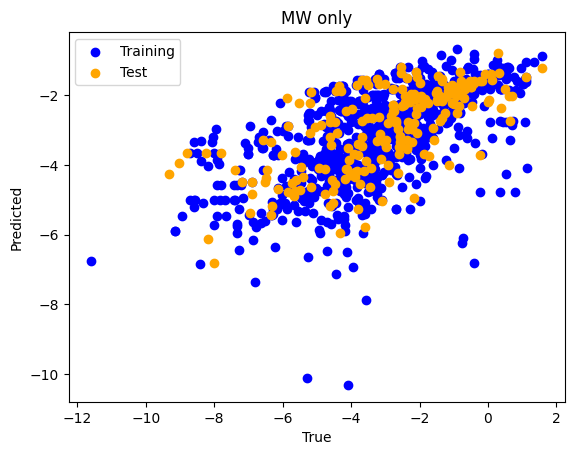

Train MW and HBD MAE: 1.0687603165774655
Train MW and HBD RMSE: 1.4076204917146034
Train MW and HBD R-squared: 0.5496143084594836
Train MW and HBD Pearson's r: PearsonRResult(statistic=0.7413597699224603, pvalue=2.5854230839134655e-160)
Test MW and HBD MAE: 0.9804258730742647
Test MW and HBD RMSE: 1.3143522658314037
Test MW and HBD R-squared: 0.6032828097693148
Test MW and HBD Pearson's r: PearsonRResult(statistic=0.7826811661393347, pvalue=1.219230907748467e-48)


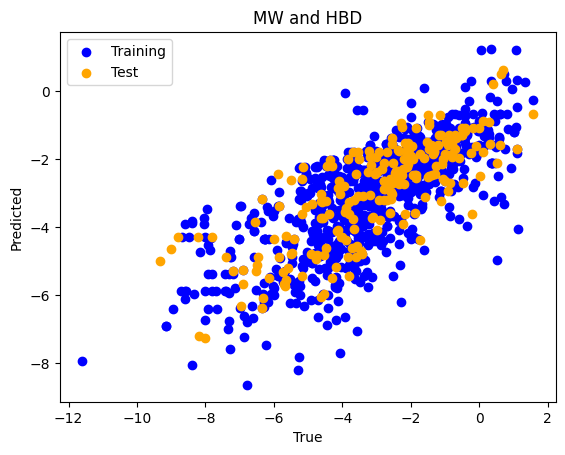

Train FP MAE: 0.08144557316681075
Train FP RMSE: 0.30787931311005795
Train FP R-squared: 0.978453613713997
Train FP Pearson's r: PearsonRResult(statistic=0.9891681495387169, pvalue=0.0)
Test FP MAE: 3423.062981049716
Test FP RMSE: 5354.016865474431
Test FP R-squared: -6582894.074318883
Test FP Pearson's r: PearsonRResult(statistic=-0.02139386321826967, pvalue=0.7474427540981315)


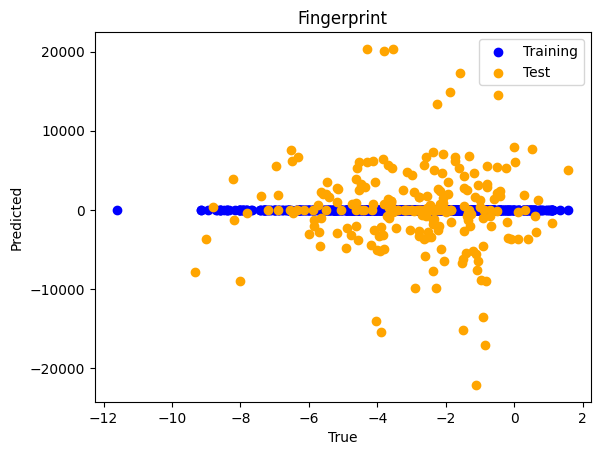

In [3]:
from sklearn import linear_model
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score
from scipy.stats import pearsonr
import matplotlib.pyplot as plt

reg_mw = linear_model.LinearRegression()
reg_mw.fit(train_df[["mw"]],train_df["measured log(solubility:mol/L)"])
train_mw_pred = reg_mw.predict(train_df[["mw"]])
test_mw_pred = reg_mw.predict(test_df[["mw"]])
print("Train MW MAE: " + str(mean_absolute_error(train_df["measured log(solubility:mol/L)"],train_mw_pred)))
print("Train MW RMSE: " + str(root_mean_squared_error(train_df["measured log(solubility:mol/L)"],train_mw_pred)))
print("Train MW R-squared: " + str(r2_score(train_df["measured log(solubility:mol/L)"],train_mw_pred)))
print("Train MW Pearson's r: " + str(pearsonr(train_df["measured log(solubility:mol/L)"],train_mw_pred)))
print("Test MW MAE: " + str(mean_absolute_error(test_df["measured log(solubility:mol/L)"],test_mw_pred)))
print("Test MW RMSE: " + str(root_mean_squared_error(test_df["measured log(solubility:mol/L)"],test_mw_pred)))
print("Test MW R-squared: " + str(r2_score(test_df["measured log(solubility:mol/L)"],test_mw_pred)))
print("Test MW Pearson's r: " + str(pearsonr(test_df["measured log(solubility:mol/L)"],test_mw_pred)))

# Create a scatter plot
plt.scatter(train_df["measured log(solubility:mol/L)"], train_mw_pred, color='blue', label='Training')
plt.scatter(test_df["measured log(solubility:mol/L)"], test_mw_pred,color='orange', label='Test')
plt.legend()

# Add labels and title
plt.xlabel('True')
plt.ylabel('Predicted')
plt.title('MW only')

# Display the plot
plt.show()

reg_mw_hbd = linear_model.LinearRegression()
reg_mw_hbd.fit(train_df[["hbd","mw"]],train_df["measured log(solubility:mol/L)"])
train_mw_hbd_pred = reg_mw_hbd.predict(train_df[["hbd","mw"]])
test_mw_hbd_pred = reg_mw_hbd.predict(test_df[["hbd","mw"]])
print("Train MW and HBD MAE: " + str(mean_absolute_error(train_df["measured log(solubility:mol/L)"],train_mw_hbd_pred)))
print("Train MW and HBD RMSE: " + str(root_mean_squared_error(train_df["measured log(solubility:mol/L)"],train_mw_hbd_pred)))
print("Train MW and HBD R-squared: " + str(r2_score(train_df["measured log(solubility:mol/L)"],train_mw_hbd_pred)))
print("Train MW and HBD Pearson's r: " + str(pearsonr(train_df["measured log(solubility:mol/L)"],train_mw_hbd_pred)))
print("Test MW and HBD MAE: " + str(mean_absolute_error(test_df["measured log(solubility:mol/L)"],test_mw_hbd_pred)))
print("Test MW and HBD RMSE: " + str(root_mean_squared_error(test_df["measured log(solubility:mol/L)"],test_mw_hbd_pred)))
print("Test MW and HBD R-squared: " + str(r2_score(test_df["measured log(solubility:mol/L)"],test_mw_hbd_pred)))
print("Test MW and HBD Pearson's r: " + str(pearsonr(test_df["measured log(solubility:mol/L)"],test_mw_hbd_pred)))

# Create a scatter plot
plt.scatter(train_df["measured log(solubility:mol/L)"], train_mw_hbd_pred,color='blue', label='Training')
plt.scatter(test_df["measured log(solubility:mol/L)"], test_mw_hbd_pred, color='orange', label='Test')
plt.legend()

# Add labels and title
plt.xlabel('True')
plt.ylabel('Predicted')
plt.title('MW and HBD')

# Display the plot
plt.show()

reg_fp = linear_model.LinearRegression()
reg_fp.fit(np.stack(train_df["fp"].values),train_df["measured log(solubility:mol/L)"])
train_fp_pred = reg_fp.predict(np.stack(train_df["fp"].values))
test_fp_pred = reg_fp.predict(np.stack(test_df["fp"].values))
print("Train FP MAE: " + str(mean_absolute_error(train_df["measured log(solubility:mol/L)"],train_fp_pred)))
print("Train FP RMSE: " + str(root_mean_squared_error(train_df["measured log(solubility:mol/L)"],train_fp_pred)))
print("Train FP R-squared: " + str(r2_score(train_df["measured log(solubility:mol/L)"],train_fp_pred)))
print("Train FP Pearson's r: " + str(pearsonr(train_df["measured log(solubility:mol/L)"],train_fp_pred)))
print("Test FP MAE: " + str(mean_absolute_error(test_df["measured log(solubility:mol/L)"],test_fp_pred)))
print("Test FP RMSE: " + str(root_mean_squared_error(test_df["measured log(solubility:mol/L)"],test_fp_pred)))
print("Test FP R-squared: " + str(r2_score(test_df["measured log(solubility:mol/L)"],test_fp_pred)))
print("Test FP Pearson's r: " + str(pearsonr(test_df["measured log(solubility:mol/L)"],test_fp_pred)))

# Create a scatter plot
plt.scatter(train_df["measured log(solubility:mol/L)"],train_fp_pred,color='blue', label='Training')
plt.scatter(test_df["measured log(solubility:mol/L)"],test_fp_pred,color='orange', label='Test')
plt.legend()

# Add labels and title
plt.xlabel('True')
plt.ylabel('Predicted')
plt.title('Fingerprint')

# Display the plot
plt.show()

# Ridge, Lasso, and ElasticNet
We can see above that the finger print model is very overfit, likely because each fingerprint is a feature. We can use ridge, lasso, and elasticnet regression to avoid overfitting.

Ridge FP MAE: 0.904206393287692
Lasso FP MAE: 1.6825246154335387
ElasticNet FP MAE: 1.645804819998262


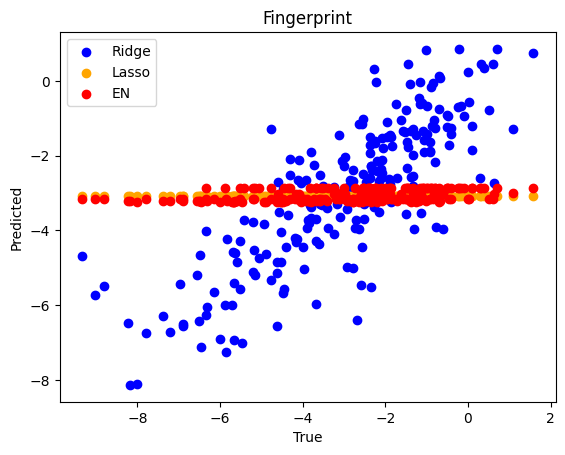

In [4]:
from sklearn import linear_model

ridge = linear_model.Ridge(alpha=.5) #alpha sets the strength of the Ridge penalty, try adjusting it and see how it affects results
ridge.fit(np.stack(train_df["fp"].values),train_df["measured log(solubility:mol/L)"])
ridge_test_predict = ridge.predict(np.stack(test_df["fp"].values))

lasso = linear_model.Lasso(alpha=0.5) #try adjusting alpha
lasso.fit(np.stack(train_df["fp"].values),train_df["measured log(solubility:mol/L)"])
lasso_test_predict = lasso.predict(np.stack(test_df["fp"].values))

en = linear_model.ElasticNet(alpha=0.5,l1_ratio=0.5) #try adjusting alpha and l1 ratio (controls balance between lasso + ridge)
en.fit(np.stack(train_df["fp"].values),train_df["measured log(solubility:mol/L)"])
en_test_predict = en.predict(np.stack(test_df["fp"].values))

#calculate MAE metric
print("Ridge FP MAE: " + str(mean_absolute_error(test_df["measured log(solubility:mol/L)"],ridge_test_predict)))
print("Lasso FP MAE: " + str(mean_absolute_error(test_df["measured log(solubility:mol/L)"],lasso_test_predict)))
print("ElasticNet FP MAE: " + str(mean_absolute_error(test_df["measured log(solubility:mol/L)"],en_test_predict)))

plt.scatter(test_df["measured log(solubility:mol/L)"],ridge_test_predict,color='blue', label='Ridge')
plt.scatter(test_df["measured log(solubility:mol/L)"],lasso_test_predict,color='orange', label='Lasso')
plt.scatter(test_df["measured log(solubility:mol/L)"],en_test_predict,color='red', label='EN')
plt.legend()

# Add labels and title
plt.xlabel('True')
plt.ylabel('Predicted')
plt.title('Fingerprint')

# Display the plot
plt.show()

# Support Vector Machine
Like with SVM classifiers, we can have different kernels, let's compare and see which works best for our solubility prediction from fingerprint

RBF FP MAE: 0.8209358006118899
Linear FP MAE: 1.173881239096486
Poly FP MAE: 0.8259820941285372


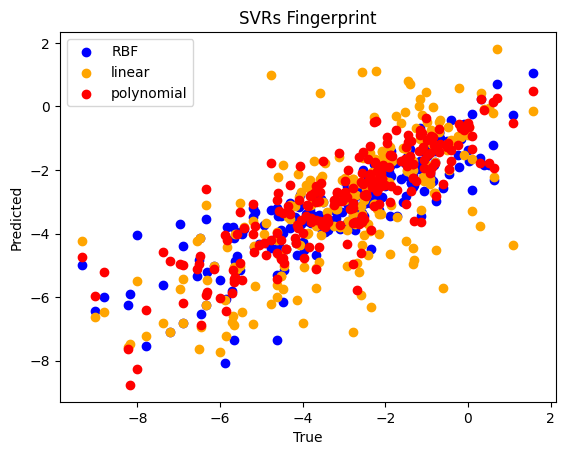

In [5]:
from sklearn.svm import SVR

#you can try adjusting gamma and epsilon to see how accuracy is affected
svr_rbf = SVR(kernel="rbf", C=100, gamma=0.1, epsilon=0.1)
svr_lin = SVR(kernel="linear", C=100, gamma="auto")
svr_poly = SVR(kernel="poly", C=100, gamma="auto", degree=3, epsilon=0.1, coef0=1)

#fit models
svr_rbf.fit(np.stack(train_df["fp"].values),train_df["measured log(solubility:mol/L)"])
svr_lin.fit(np.stack(train_df["fp"].values),train_df["measured log(solubility:mol/L)"])
svr_poly.fit(np.stack(train_df["fp"].values),train_df["measured log(solubility:mol/L)"])

#predict
rbf_test_predict = svr_rbf.predict(np.stack(test_df["fp"].values))
lin_test_predict = svr_lin.predict(np.stack(test_df["fp"].values))
poly_test_predict = svr_poly.predict(np.stack(test_df["fp"].values))

#MAE metric
print("RBF FP MAE: " + str(mean_absolute_error(test_df["measured log(solubility:mol/L)"],rbf_test_predict)))
print("Linear FP MAE: " + str(mean_absolute_error(test_df["measured log(solubility:mol/L)"],lin_test_predict)))
print("Poly FP MAE: " + str(mean_absolute_error(test_df["measured log(solubility:mol/L)"],poly_test_predict)))

#plot
plt.scatter(test_df["measured log(solubility:mol/L)"],rbf_test_predict,color='blue', label='RBF')
plt.scatter(test_df["measured log(solubility:mol/L)"],lin_test_predict,color='orange', label='linear')
plt.scatter(test_df["measured log(solubility:mol/L)"],poly_test_predict,color='red', label='polynomial')
plt.legend()

# Add labels and title
plt.xlabel('True')
plt.ylabel('Predicted')
plt.title('SVRs Fingerprint')

# Display the plot
plt.show()

# Random forest regression

RFR MAE: 0.9170983758987253


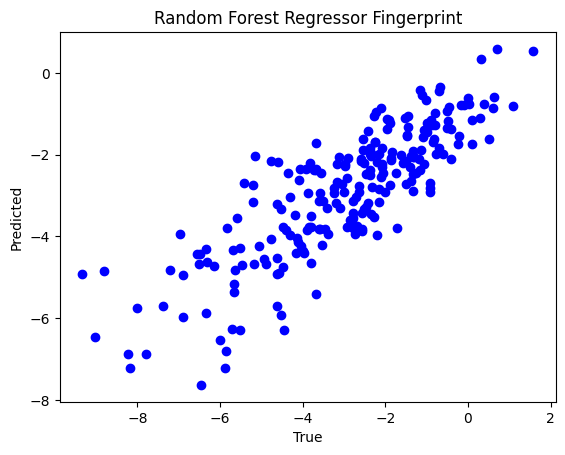

In [6]:
from sklearn.ensemble import RandomForestRegressor

#Random forest regressor using fingerprints as features
rfr = RandomForestRegressor(n_estimators=10)
rfr.fit(np.stack(train_df["fp"].values),train_df["measured log(solubility:mol/L)"])
rfr_test_predict = rfr.predict(np.stack(test_df["fp"].values))

#MAE metric
print("RFR MAE: " + str(mean_absolute_error(test_df["measured log(solubility:mol/L)"],rfr_test_predict)))
#plot
plt.scatter(test_df["measured log(solubility:mol/L)"],rfr_test_predict,color='blue')


# Add labels and title
plt.xlabel('True')
plt.ylabel('Predicted')
plt.title('Random Forest Regressor Fingerprint')

# Display the plot
plt.show()

# GridSearchCV for regression
Grid search works similarly to classificaiton case, just need to choose an appropriate metric. RMSE or MSE are good choices depending on if your data has outliers. MSE better for outliers because the square difference on the outlier will not overpower other errors. Note you will need to make them use the negative version of these scores so that the higher scoring models are better because GridSearchCV selects the model with the highest score.

Fitting 5 folds for each of 24 candidates, totalling 120 fits
Best parameters:
{'max_depth': None, 'max_features': 'sqrt', 'n_estimators': 300}

Best CV neg RMSE:
-1.2187320814419687
Optimized MAE: 0.8507115377555892
Optimized RMSE: 1.1309529926363395


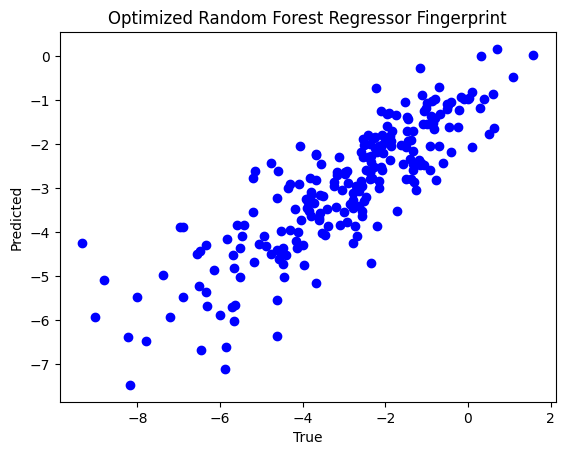

In [9]:
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.metrics import classification_report, roc_auc_score

#recreate the random forest regressor without any hyperparameters set
random_forest_regressor = RandomForestRegressor(
    random_state=42,
    n_jobs=-1
)

#define the grid of parameters you want to test the combinations of
param_grid = {
    "n_estimators": [100, 300, 500],
    "max_depth": [None, 5, 10, 20],
    "max_features": ["sqrt", "log2"],
}


#set up the grid,we need to give it our classifier, our grid, scoring, and cross validation method 
grid = GridSearchCV(
    estimator=random_forest_regressor,
    param_grid=param_grid,
    scoring={
        "neg_root_mean_squared_error": "neg_root_mean_squared_error",
        "neg_mean_absolute_error": "neg_mean_absolute_error"
    },
    refit="neg_root_mean_squared_error",      # refit best model based on RMSE
    cv=5,
    n_jobs=-1,
    verbose=2
)

grid.fit(np.stack(train_df["fp"].values), train_df["measured log(solubility:mol/L)"])

# best model
print("Best parameters:")
print(grid.best_params_)

print("\nBest CV neg RMSE:")
print(grid.best_score_)

best_model = grid.best_estimator_

#evaluate on test data
y_pred = best_model.predict(np.stack(test_df["fp"].values))

#MAE metric
print("Optimized MAE: " + str(mean_absolute_error(test_df["measured log(solubility:mol/L)"],y_pred)))
print("Optimized RMSE: " + str(root_mean_squared_error(test_df["measured log(solubility:mol/L)"],y_pred)))
#plot
plt.scatter(test_df["measured log(solubility:mol/L)"],y_pred,color='blue')


# Add labels and title
plt.xlabel('True')
plt.ylabel('Predicted')
plt.title('Optimized Random Forest Regressor Fingerprint')

# Display the plot
plt.show()